In [1]:
# ============================================================
# EMNIST 3-letter detection
# Center-Heatmap version
# Corner regulation applied only to training cache
# Train-eval and test are unblocked
# ============================================================
import os
import random
from itertools import permutations

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision.datasets import EMNIST
from torchvision.transforms import ToTensor
from torchvision.transforms import functional as TF
from torchvision.transforms import InterpolationMode

try:
    from tqdm.notebook import tqdm
except Exception:
    from tqdm import tqdm

torch.backends.cudnn.benchmark = True

try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass


# ============================================================
# Run folder
# ============================================================

RUN_DIR = "./runs_heatmap_corner_blocked_train_only"
CACHE_DIR = os.path.join(RUN_DIR, "cache")
os.makedirs(RUN_DIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)


# ============================================================
# Basic setup
# ============================================================

def seed_all(seed: int = 0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def fix_emnist_orientation(img: torch.Tensor) -> torch.Tensor:
    return torch.transpose(img, 1, 2)


def label_to_str(v, class_names=None):
    v = int(v)
    if class_names is None:
        return str(v)
    if 0 <= v < len(class_names):
        return str(class_names[v])
    return str(v)


# ============================================================
# Class-specific forbidden quadrant
# ============================================================

QUADRANT_NAMES = [
    "top_left",
    "top_right",
    "bottom_left",
    "bottom_right",
]


def build_forbidden_quadrant_by_class(num_classes=26):
    return {
        c: QUADRANT_NAMES[c % 4]
        for c in range(num_classes)
    }


def is_center_in_forbidden_quadrant(cx, cy, lab, canvas_size, forbidden_quadrant_by_class):
    if forbidden_quadrant_by_class is None:
        return False

    q = forbidden_quadrant_by_class.get(int(lab), None)
    if q is None:
        return False

    mid = canvas_size / 2.0

    if q == "top_left":
        return cx < mid and cy < mid
    if q == "top_right":
        return cx >= mid and cy < mid
    if q == "bottom_left":
        return cx < mid and cy >= mid
    if q == "bottom_right":
        return cx >= mid and cy >= mid

    raise ValueError(f"Unknown quadrant: {q}")


def print_forbidden_quadrant_map(class_names, forbidden_quadrant_by_class):
    print("training-only forbidden quadrant map:")
    for c in range(len(class_names)):
        print(f"  {label_to_str(c, class_names)} -> {forbidden_quadrant_by_class[c]}")


# ============================================================
# Geometry helpers
# ============================================================

def rect_intersection_area_xyxy(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b

    ix1 = max(ax1, bx1)
    iy1 = max(ay1, by1)
    ix2 = min(ax2, bx2)
    iy2 = min(ay2, by2)

    iw = max(0, ix2 - ix1)
    ih = max(0, iy2 - iy1)

    return iw * ih


def rect_center_distance_sq(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b

    acx = 0.5 * (ax1 + ax2)
    acy = 0.5 * (ay1 + ay2)

    bcx = 0.5 * (bx1 + bx2)
    bcy = 0.5 * (by1 + by2)

    return (acx - bcx) ** 2 + (acy - bcy) ** 2


def box_iou_xyxy(a, b, eps=1e-6):
    ax1, ay1, ax2, ay2 = a.unbind(-1)
    bx1, by1, bx2, by2 = b.unbind(-1)

    ix1 = torch.maximum(ax1, bx1)
    iy1 = torch.maximum(ay1, by1)
    ix2 = torch.minimum(ax2, bx2)
    iy2 = torch.minimum(ay2, by2)

    iw = (ix2 - ix1).clamp(min=0.0)
    ih = (iy2 - iy1).clamp(min=0.0)
    inter = iw * ih

    area_a = (ax2 - ax1).clamp(min=0.0) * (ay2 - ay1).clamp(min=0.0)
    area_b = (bx2 - bx1).clamp(min=0.0) * (by2 - by1).clamp(min=0.0)

    union = area_a + area_b - inter + eps

    return inter / union


def best_match_perm_l1(pred_boxes, gt_boxes):
    k = pred_boxes.shape[0]
    all_perms = list(permutations(range(k)))

    best_p = None
    best_cost = None

    for p in all_perms:
        cost = 0.0

        for i in range(k):
            cost += (pred_boxes[i] - gt_boxes[p[i]]).abs().mean().item()

        if best_cost is None or cost < best_cost:
            best_cost = cost
            best_p = p

    return best_p


_PERM_CACHE = {}


def get_perm_tensor(k, device):
    key = (k, str(device))

    if key not in _PERM_CACHE:
        perms = list(permutations(range(k)))
        _PERM_CACHE[key] = torch.tensor(perms, dtype=torch.long, device=device)

    return _PERM_CACHE[key]


def match_by_l1_batch(pred_boxes, gt_boxes, gt_labels):
    B, K, _ = pred_boxes.shape
    device = pred_boxes.device

    perms = get_perm_tensor(K, device)

    all_costs = []

    for p in perms:
        gt_perm = gt_boxes[:, p, :]
        cost = (pred_boxes - gt_perm).abs().mean(dim=(1, 2))
        all_costs.append(cost)

    all_costs = torch.stack(all_costs, dim=1)
    best_idx = all_costs.argmin(dim=1)

    selected_perm = perms[best_idx]

    box_index = selected_perm[:, :, None].expand(B, K, 4)
    matched_boxes = gt_boxes.gather(dim=1, index=box_index)

    matched_labels = gt_labels.gather(dim=1, index=selected_perm)

    return matched_boxes, matched_labels


# ============================================================
# Safe augmentation
# ============================================================

def augment_emnist_letter(img, rng):
    if rng.random() < 0.80:
        angle = rng.uniform(-10.0, 10.0)
        scale = rng.uniform(0.92, 1.08)

        img = TF.affine(
            img,
            angle=angle,
            translate=(0, 0),
            scale=scale,
            shear=(0.0, 0.0),
            interpolation=InterpolationMode.BILINEAR,
            fill=0.0,
        )

    if rng.random() < 0.20:
        factor = rng.uniform(0.90, 1.10)
        img = (img * factor).clamp(0.0, 1.0)

    if rng.random() < 0.15:
        noise_std = rng.uniform(0.005, 0.02)
        img = (img + torch.randn_like(img) * noise_std).clamp(0.0, 1.0)

    return img.clamp(0.0, 1.0)


# ============================================================
# Fast integer-center rendering
# ============================================================

def center_is_valid(cx, cy, placed_centers, object_size=28, min_separation=2):
    gap = object_size + min_separation

    for pcx, pcy in placed_centers:
        too_close_x = abs(cx - pcx) < gap
        too_close_y = abs(cy - pcy) < gap

        if too_close_x and too_close_y:
            return False

    return True


def sample_center_fast(
    rng,
    canvas_size,
    object_size=28,
    placed_centers=None,
    min_separation=2,
    allow_overlap=False,
    tries=80,
    lab=None,
    forbidden_quadrant_by_class=None,
):
    if placed_centers is None:
        placed_centers = []

    half = object_size // 2

    min_c = half
    max_c = canvas_size - half

    for _ in range(tries):
        cx = rng.randint(min_c, max_c)
        cy = rng.randint(min_c, max_c)

        if is_center_in_forbidden_quadrant(
            cx=cx,
            cy=cy,
            lab=lab,
            canvas_size=canvas_size,
            forbidden_quadrant_by_class=forbidden_quadrant_by_class,
        ):
            continue

        if allow_overlap:
            return cx, cy

        if center_is_valid(
            cx,
            cy,
            placed_centers,
            object_size=object_size,
            min_separation=min_separation,
        ):
            return cx, cy

    best_center = None
    best_score = None
    gap = object_size + min_separation

    for cx in range(min_c, max_c + 1):
        for cy in range(min_c, max_c + 1):
            if is_center_in_forbidden_quadrant(
                cx=cx,
                cy=cy,
                lab=lab,
                canvas_size=canvas_size,
                forbidden_quadrant_by_class=forbidden_quadrant_by_class,
            ):
                continue

            score = 0.0

            for pcx, pcy in placed_centers:
                vx = max(0, gap - abs(cx - pcx))
                vy = max(0, gap - abs(cy - pcy))
                score += vx * vy

            if best_score is None or score < best_score:
                best_score = score
                best_center = (cx, cy)

            if score == 0.0:
                return cx, cy

    if best_center is None:
        raise RuntimeError(f"No legal center found for label {lab}")

    if best_score is not None and best_score > 0.0 and not allow_overlap:
        raise RuntimeError(f"No non-overlap center found for label {lab}")

    return best_center


def render_boxes_on_canvas(
    canvas_size,
    char_imgs,
    char_labels,
    rng,
    allow_overlap=False,
    placement_tries=80,
    min_separation=2,
    forbidden_quadrant_by_class=None,
):
    H = W = int(canvas_size)
    object_size = 28
    half = object_size // 2

    canvas = torch.zeros(1, H, W, dtype=torch.float32)

    boxes_norm = []
    labels = []
    placed_centers = []

    for img, lab in zip(char_imgs, char_labels):
        h, w = img.shape[-2], img.shape[-1]

        if h != 28 or w != 28:
            raise ValueError(f"Expected 28x28 EMNIST character, got {h}x{w}")

        cx, cy = sample_center_fast(
            rng=rng,
            canvas_size=canvas_size,
            object_size=object_size,
            placed_centers=placed_centers,
            min_separation=min_separation,
            allow_overlap=allow_overlap,
            tries=placement_tries,
            lab=lab,
            forbidden_quadrant_by_class=forbidden_quadrant_by_class,
        )

        placed_centers.append((cx, cy))

        x = cx - half
        y = cy - half

        patch = canvas[:, y:y + h, x:x + w]
        canvas[:, y:y + h, x:x + w] = torch.maximum(patch, img)

        x1 = x / W
        y1 = y / H
        x2 = (x + w) / W
        y2 = (y + h) / H

        boxes_norm.append(torch.tensor([x1, y1, x2, y2], dtype=torch.float32))
        labels.append(int(lab))

    boxes = torch.stack(boxes_norm, dim=0)
    labels = torch.tensor(labels, dtype=torch.long)

    return canvas, boxes, labels


# ============================================================
# Dataset
# ============================================================

class ThreeCharEMNIST(Dataset):
    def __init__(
        self,
        root="./data",
        train=True,
        split="letters",
        canvas_size=64,
        chars_per_image=3,
        length=5000,
        seed=1,
        allow_overlap=False,
        placement_tries=80,
        min_separation=2,
        augment=False,
        use_class_corner_blocking=False,
        max_canvas_resample=100,
    ):
        self.split = split

        self.ds = EMNIST(
            root=root,
            split=split,
            train=train,
            download=True,
            transform=ToTensor(),
        )

        self.canvas_size = int(canvas_size)
        self.k = int(chars_per_image)
        self.length = int(length)
        self.base_seed = int(seed)
        self.train = bool(train)
        self.allow_overlap = bool(allow_overlap)
        self.placement_tries = int(placement_tries)
        self.min_separation = int(min_separation)
        self.augment = bool(augment)
        self.use_class_corner_blocking = bool(use_class_corner_blocking)
        self.max_canvas_resample = int(max_canvas_resample)

        self.num_classes = self._infer_num_classes(split)
        self.class_names = self._build_class_names(split)

        if self.use_class_corner_blocking:
            self.forbidden_quadrant_by_class = build_forbidden_quadrant_by_class(self.num_classes)
        else:
            self.forbidden_quadrant_by_class = None

    @staticmethod
    def _infer_num_classes(split):
        if split in {"digits", "mnist"}:
            return 10
        if split == "letters":
            return 26
        if split in {"balanced", "bymerge"}:
            return 47
        if split == "byclass":
            return 62
        raise ValueError(f"Unknown EMNIST split: {split}")

    @staticmethod
    def _build_class_names(split):
        if split in {"digits", "mnist"}:
            return [str(i) for i in range(10)]
        if split == "letters":
            return [chr(ord("a") + i) for i in range(26)]

        n = ThreeCharEMNIST._infer_num_classes(split)
        return [str(i) for i in range(n)]

    def _normalize_label(self, lab):
        lab = int(lab)
        if self.split == "letters":
            return lab - 1
        return lab

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        base_rng = random.Random(self.base_seed + idx + (0 if self.train else 10_000_000))
        n = len(self.ds)

        for _ in range(self.max_canvas_resample):
            rng = random.Random(base_rng.randint(0, 2**31 - 1))

            char_imgs = []
            char_labels = []

            for _ in range(self.k):
                j = rng.randint(0, n - 1)

                img, lab = self.ds[j]
                img = fix_emnist_orientation(img)

                if self.train and self.augment:
                    img = augment_emnist_letter(img, rng)

                lab = self._normalize_label(lab)

                char_imgs.append(img)
                char_labels.append(lab)

            try:
                canvas, boxes, labels = render_boxes_on_canvas(
                    canvas_size=self.canvas_size,
                    char_imgs=char_imgs,
                    char_labels=char_labels,
                    rng=rng,
                    allow_overlap=self.allow_overlap,
                    placement_tries=self.placement_tries,
                    min_separation=self.min_separation,
                    forbidden_quadrant_by_class=self.forbidden_quadrant_by_class,
                )

                return canvas, boxes, labels

            except RuntimeError:
                continue

        raise RuntimeError(
            f"Could not generate valid canvas after {self.max_canvas_resample} attempts. "
            f"Try increasing placement_tries or reducing min_separation."
        )


class CachedThreeCharDataset(Dataset):
    def __init__(self, cache_path, source_ds=None, rebuild=False):
        self.cache_path = cache_path

        if os.path.exists(cache_path) and not rebuild:
            obj = torch.load(cache_path, map_location="cpu")

            self.images = obj["images"]
            self.boxes = obj["boxes"]
            self.labels = obj["labels"]
            self.num_classes = obj["num_classes"]
            self.class_names = obj["class_names"]
            self.k = obj["k"]
            self.canvas_size = obj["canvas_size"]
            self.use_class_corner_blocking = obj.get("use_class_corner_blocking", False)
            self.forbidden_quadrant_by_class = obj.get("forbidden_quadrant_by_class", None)

            return

        if source_ds is None:
            raise ValueError("source_ds is required when building a new cache")

        n = len(source_ds)
        canvas_size = source_ds.canvas_size
        k = source_ds.k

        images = torch.empty(n, 1, canvas_size, canvas_size, dtype=torch.uint8)
        boxes = torch.empty(n, k, 4, dtype=torch.float32)
        labels = torch.empty(n, k, dtype=torch.long)
        print('start building')
        for i in tqdm(range(n), desc=f"building cache {cache_path}"):
            if i%1000==0:
                print(i)
            x, b, y = source_ds[i]

            images[i] = (x * 255).clamp(0, 255).byte()
            boxes[i] = b
            labels[i] = y

        obj = {
            "images": images,
            "boxes": boxes,
            "labels": labels,
            "num_classes": source_ds.num_classes,
            "class_names": source_ds.class_names,
            "k": source_ds.k,
            "canvas_size": source_ds.canvas_size,
            "use_class_corner_blocking": source_ds.use_class_corner_blocking,
            "forbidden_quadrant_by_class": source_ds.forbidden_quadrant_by_class,
        }

        os.makedirs(os.path.dirname(cache_path), exist_ok=True)
        torch.save(obj, cache_path)

        self.images = images
        self.boxes = boxes
        self.labels = labels
        self.num_classes = source_ds.num_classes
        self.class_names = source_ds.class_names
        self.k = source_ds.k
        self.canvas_size = source_ds.canvas_size
        self.use_class_corner_blocking = source_ds.use_class_corner_blocking
        self.forbidden_quadrant_by_class = source_ds.forbidden_quadrant_by_class

    def __len__(self):
        return self.images.shape[0]

    def __getitem__(self, idx):
        x = self.images[idx].float() / 255.0
        b = self.boxes[idx]
        y = self.labels[idx]

        return x, b, y


# ============================================================
# Center-heatmap model
# ============================================================

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class ResidualBlock(nn.Module):
    def __init__(self, ch, dilation=1):
        super().__init__()

        self.conv1 = nn.Conv2d(
            ch,
            ch,
            3,
            padding=dilation,
            dilation=dilation,
            bias=False,
        )

        self.bn1 = nn.BatchNorm2d(ch)

        self.conv2 = nn.Conv2d(
            ch,
            ch,
            3,
            padding=dilation,
            dilation=dilation,
            bias=False,
        )

        self.bn2 = nn.BatchNorm2d(ch)

    def forward(self, x):
        z = self.conv1(x)
        z = self.bn1(z)
        z = F.relu(z, inplace=True)

        z = self.conv2(z)
        z = self.bn2(z)

        return F.relu(x + z, inplace=True)


class CenterHeatmapDetector(nn.Module):
    def __init__(
        self,
        num_classes=26,
        base_ch=64,
        canvas_size=64,
        object_size=28,
    ):
        super().__init__()

        self.num_classes = int(num_classes)
        self.canvas_size = int(canvas_size)
        self.object_size = int(object_size)

        self.stem = nn.Sequential(
            ConvBlock(1, base_ch),
            ConvBlock(base_ch, base_ch),
        )

        self.body = nn.Sequential(
            ResidualBlock(base_ch, dilation=1),
            ResidualBlock(base_ch, dilation=2),
            ResidualBlock(base_ch, dilation=3),
            ResidualBlock(base_ch, dilation=4),
            ResidualBlock(base_ch, dilation=1),
        )

        self.head = nn.Sequential(
            ConvBlock(base_ch, base_ch),
            nn.Conv2d(base_ch, self.num_classes, 1),
        )

        self._init_heatmap_bias()

    def _init_heatmap_bias(self):
        final_conv = self.head[-1]
        nn.init.constant_(final_conv.bias, -4.0)

    def forward(self, x):
        z = self.stem(x)
        z = self.body(z)
        logits = self.head(z)
        return logits


# ============================================================
# Heatmap targets, loss, decoding
# ============================================================

def make_valid_center_mask(
    canvas_size=64,
    object_size=28,
    device="cpu",
):
    half = object_size // 2

    valid = torch.zeros(
        1,
        1,
        canvas_size,
        canvas_size,
        dtype=torch.float32,
        device=device,
    )

    valid[:, :, half:canvas_size - half + 1, half:canvas_size - half + 1] = 1.0

    return valid


def boxes_to_integer_centers_px(gt_boxes, canvas_size=64):
    cx = ((gt_boxes[..., 0] + gt_boxes[..., 2]) * 0.5 * canvas_size).round().long()
    cy = ((gt_boxes[..., 1] + gt_boxes[..., 3]) * 0.5 * canvas_size).round().long()

    cx = cx.clamp(0, canvas_size - 1)
    cy = cy.clamp(0, canvas_size - 1)

    return cx, cy


def build_center_heatmap_targets(
    gt_boxes,
    gt_labels,
    num_classes=26,
    canvas_size=64,
    radius=1,
    sigma=1.0,
):
    B, K, _ = gt_boxes.shape
    device = gt_boxes.device

    targets = torch.zeros(
        B,
        num_classes,
        canvas_size,
        canvas_size,
        dtype=torch.float32,
        device=device,
    )

    gt_cx, gt_cy = boxes_to_integer_centers_px(
        gt_boxes,
        canvas_size=canvas_size,
    )

    b_idx = torch.arange(B, device=device)[:, None].expand(B, K)

    flat_idx = (
        ((b_idx * num_classes + gt_labels) * canvas_size + gt_cy) * canvas_size + gt_cx
    )

    targets.view(-1)[flat_idx.reshape(-1)] = 1.0

    if radius > 0:
        size = 2 * radius + 1

        coords = torch.arange(
            -radius,
            radius + 1,
            device=device,
            dtype=torch.float32,
        )

        yy, xx = torch.meshgrid(coords, coords, indexing="ij")

        kernel = torch.exp(
            -((xx ** 2 + yy ** 2) / (2.0 * sigma ** 2))
        )

        kernel = kernel / kernel.max()
        kernel = kernel.view(1, 1, size, size)
        kernel = kernel.expand(num_classes, 1, size, size)

        targets = F.conv2d(
            targets,
            kernel,
            padding=radius,
            groups=num_classes,
        )

        targets = targets.clamp(0.0, 1.0)

    return targets


def heatmap_focal_loss(
    logits,
    targets,
    valid_mask=None,
    alpha=2.0,
    beta=4.0,
):
    pred = torch.sigmoid(logits).clamp(1e-4, 1.0 - 1e-4)

    pos = targets.eq(1.0).float()
    neg = targets.lt(1.0).float()

    neg_weights = (1.0 - targets).pow(beta)

    if valid_mask is not None:
        pos = pos * valid_mask
        neg = neg * valid_mask
        neg_weights = neg_weights * valid_mask

    pos_loss = -torch.log(pred) * (1.0 - pred).pow(alpha) * pos
    neg_loss = -torch.log(1.0 - pred) * pred.pow(alpha) * neg_weights * neg

    num_pos = pos.sum().clamp(min=1.0)

    loss = (pos_loss.sum() + neg_loss.sum()) / num_pos

    return loss


def centers_to_boxes_from_int(
    cx,
    cy,
    canvas_size=64,
    object_size=28,
):
    half = object_size // 2

    x1 = (cx.float() - half) / float(canvas_size)
    y1 = (cy.float() - half) / float(canvas_size)
    x2 = (cx.float() + half) / float(canvas_size)
    y2 = (cy.float() + half) / float(canvas_size)

    boxes = torch.stack([x1, y1, x2, y2], dim=-1)

    return boxes.clamp(0.0, 1.0)


def nms_heatmap(prob, kernel=3):
    pad = kernel // 2

    pooled = F.max_pool2d(
        prob,
        kernel_size=kernel,
        stride=1,
        padding=pad,
    )

    keep = pooled.eq(prob)

    return prob * keep.float()


@torch.no_grad()
def decode_heatmap_topk(
    logits,
    k=3,
    canvas_size=64,
    object_size=28,
):
    B, C, H, W = logits.shape
    device = logits.device

    prob = torch.sigmoid(logits)

    valid_mask = make_valid_center_mask(
        canvas_size=canvas_size,
        object_size=object_size,
        device=device,
    )

    prob = prob * valid_mask
    prob = nms_heatmap(prob, kernel=3)

    flat = prob.reshape(B, -1)

    scores, inds = torch.topk(flat, k=k, dim=1)

    class_ids = inds // (H * W)
    rem = inds % (H * W)

    cy = rem // W
    cx = rem % W

    boxes = centers_to_boxes_from_int(
        cx=cx,
        cy=cy,
        canvas_size=canvas_size,
        object_size=object_size,
    )

    return boxes, class_ids.long(), scores


# ============================================================
# Evaluation
# ============================================================

@torch.no_grad()
def evaluate_heatmap_detector(
    model,
    loader,
    device,
    num_classes=26,
    canvas_size=64,
    object_size=28,
    k=3,
    iou_threshold=0.5,
    target_radius=1,
    max_batches=None,
):
    model.eval()

    valid_mask = make_valid_center_mask(
        canvas_size=canvas_size,
        object_size=object_size,
        device=device,
    )

    total_loss = 0.0
    num_batches = 0

    total_images = 0
    total_objects = 0

    correct_cls = 0
    total_iou = 0.0
    total_box_l1 = 0.0
    correct_det = 0
    exact_set_correct = 0

    for batch_idx, (x, gt_boxes, gt_labels) in enumerate(loader):
        x = x.to(device, non_blocking=True)
        gt_boxes = gt_boxes.to(device, non_blocking=True)
        gt_labels = gt_labels.to(device, non_blocking=True)

        logits = model(x)

        targets = build_center_heatmap_targets(
            gt_boxes=gt_boxes,
            gt_labels=gt_labels,
            num_classes=num_classes,
            canvas_size=canvas_size,
            radius=target_radius,
            sigma=1.0,
        )

        loss = heatmap_focal_loss(
            logits=logits,
            targets=targets,
            valid_mask=valid_mask,
        )

        total_loss += float(loss.item())
        num_batches += 1

        pred_boxes, pred_labels, pred_scores = decode_heatmap_topk(
            logits=logits,
            k=k,
            canvas_size=canvas_size,
            object_size=object_size,
        )

        matched_gt_boxes, matched_gt_labels = match_by_l1_batch(
            pred_boxes=pred_boxes,
            gt_boxes=gt_boxes,
            gt_labels=gt_labels,
        )

        B, K, _ = pred_boxes.shape

        ious = box_iou_xyxy(
            pred_boxes.reshape(-1, 4),
            matched_gt_boxes.reshape(-1, 4),
        ).reshape(B, K)

        cls_ok = pred_labels == matched_gt_labels
        det_ok = cls_ok & (ious >= iou_threshold)

        correct_cls += int(cls_ok.sum().item())
        total_iou += float(ious.sum().item())

        total_box_l1 += float(
            (pred_boxes - matched_gt_boxes)
            .abs()
            .mean(dim=-1)
            .sum()
            .item()
        )

        correct_det += int(det_ok.sum().item())
        exact_set_correct += int(det_ok.all(dim=1).sum().item())

        total_objects += B * K
        total_images += B

        if max_batches is not None and (batch_idx + 1) >= max_batches:
            break

    metrics = {
        "loss": total_loss / max(num_batches, 1),
        "cls_acc": correct_cls / max(total_objects, 1),
        "mean_iou": total_iou / max(total_objects, 1),
        "mean_box_l1": total_box_l1 / max(total_objects, 1),
        "det_acc": correct_det / max(total_objects, 1),
        "exact_set_acc": exact_set_correct / max(total_images, 1),
        "num_images": total_images,
        "num_objects": total_objects,
    }

    return metrics


# ============================================================
# Visualization
# ============================================================

@torch.no_grad()
def show_heatmap_predictions(
    model,
    loader,
    device,
    class_names=None,
    canvas_size=64,
    object_size=28,
    k=3,
    num_images=9,
    ncols=3,
    title=None,
):
    model.eval()

    x, gt_boxes, gt_labels = next(iter(loader))

    x = x.to(device)[:num_images]
    gt_boxes = gt_boxes.to(device)[:num_images]
    gt_labels = gt_labels.to(device)[:num_images]

    logits = model(x)

    pred_boxes, pred_labels, pred_scores = decode_heatmap_topk(
        logits=logits,
        k=k,
        canvas_size=canvas_size,
        object_size=object_size,
    )

    imgs = x.detach().cpu().squeeze(1)
    pb = pred_boxes.detach().cpu()
    pl = pred_labels.detach().cpu()
    ps = pred_scores.detach().cpu()
    gb = gt_boxes.detach().cpu()
    gl = gt_labels.detach().cpu()

    matched_gb = []
    matched_gl = []
    matched_iou = []

    for i in range(num_images):
        p = best_match_perm_l1(pb[i], gb[i])
        p = torch.tensor(p, dtype=torch.long)

        mgb = gb[i][p]
        mgl = gl[i][p]
        iou = box_iou_xyxy(pb[i], mgb)

        matched_gb.append(mgb)
        matched_gl.append(mgl)
        matched_iou.append(iou)

    matched_gb = torch.stack(matched_gb)
    matched_gl = torch.stack(matched_gl)
    matched_iou = torch.stack(matched_iou)

    nrows = (num_images + ncols - 1) // ncols

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(3.2 * ncols, 3.2 * nrows),
    )

    axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

    if title is not None:
        fig.suptitle(title, fontsize=14)

    for i in range(num_images):
        ax = axes[i]
        ax.imshow(imgs[i], cmap="gray", vmin=0, vmax=1)
        ax.axis("off")

        for j in range(k):
            x1, y1, x2, y2 = matched_gb[i, j].tolist()

            x1 *= canvas_size
            x2 *= canvas_size
            y1 *= canvas_size
            y2 *= canvas_size

            rect = plt.Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                fill=False,
                linewidth=1.0,
                color="white",
            )

            ax.add_patch(rect)

            ax.text(
                x1,
                y1,
                f"gt {label_to_str(matched_gl[i, j], class_names)}",
                fontsize=11,
                color="white",
            )

        for j in range(k):
            x1, y1, x2, y2 = pb[i, j].tolist()

            x1 *= canvas_size
            x2 *= canvas_size
            y1 *= canvas_size
            y2 *= canvas_size

            rect = plt.Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                fill=False,
                linewidth=1.0,
                color="red",
            )

            ax.add_patch(rect)

            ax.text(
                x1,
                y2,
                f"p {label_to_str(pl[i, j], class_names)} "
                f"{float(ps[i, j]):.2f} "
                f"iou {float(matched_iou[i, j]):.2f}",
                fontsize=11,
                color="red",
            )

    for j in range(num_images, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


# ============================================================
# Checkpoint and plotting helpers
# ============================================================

def save_checkpoint_heatmap(
    path,
    model,
    emnist_split,
    num_classes,
    class_names,
    k,
    canvas_size,
    object_size,
    extra=None,
):
    payload = {
        "model": model.state_dict(),
        "model_state_dict": model.state_dict(),
        "architecture": "center_heatmap_detector",
        "emnist_split": emnist_split,
        "num_classes": num_classes,
        "class_names": class_names,
        "k": k,
        "canvas_size": canvas_size,
        "object_size": object_size,
        "run_dir": RUN_DIR,
    }

    if extra is not None:
        payload.update(extra)

    torch.save(payload, path)


def plot_heatmap_training_curves(history):
    plt.figure(figsize=(4, 3))
    plt.plot(history["train_log_steps"], history["train_batch_loss"], label="train batch loss")
    plt.xlabel("global step")
    plt.ylabel("loss")
    plt.title("Training loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(4, 3))
    plt.plot(history["eval_steps"], history["train_eval_loss"], label="train eval loss")
    plt.plot(history["eval_steps"], history["val_loss"], label="test loss")
    plt.xlabel("global step")
    plt.ylabel("loss")
    plt.title("Train vs test loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(4, 3))
    plt.plot(history["eval_steps"], history["train_cls_acc"], label="train cls acc")
    plt.plot(history["eval_steps"], history["val_cls_acc"], label="test cls acc")
    plt.xlabel("global step")
    plt.ylabel("accuracy")
    plt.title("Classification accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(4, 3))
    plt.plot(history["eval_steps"], history["train_det_acc"], label="train det acc")
    plt.plot(history["eval_steps"], history["val_det_acc"], label="test det acc")
    plt.xlabel("global step")
    plt.ylabel("accuracy")
    plt.title("Detection accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(4, 3))
    plt.plot(history["eval_steps"], history["train_exact_set_acc"], label="train exact")
    plt.plot(history["eval_steps"], history["val_exact_set_acc"], label="test exact")
    plt.xlabel("global step")
    plt.ylabel("accuracy")
    plt.title("Exact set accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(4, 3))
    plt.plot(history["eval_steps"], history["train_mean_iou"], label="train IoU")
    plt.plot(history["eval_steps"], history["val_mean_iou"], label="test IoU")
    plt.xlabel("global step")
    plt.ylabel("IoU")
    plt.title("Mean IoU")
    plt.legend()
    plt.tight_layout()
    plt.show()


# ============================================================
# Main training
# ============================================================

rebuild_cache = False

seed_all(0)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device", device)

canvas_size = 64
object_size = 28
k = 3

train_length = 240000
train_eval_length = 5000
val_length = 5000

batch_size = 512

viz_every = 3000
eval_every = 3000
log_every = 100
epochs = 90

target_radius = 1
emnist_split = "letters"

raw_train_ds = ThreeCharEMNIST(
    root="./data",
    train=True,
    split=emnist_split,
    canvas_size=canvas_size,
    chars_per_image=k,
    length=train_length,
    seed=0,
    allow_overlap=False,
    placement_tries=300,
    min_separation=2,
    augment=True,
    use_class_corner_blocking=True,
    max_canvas_resample=100,
)

raw_train_eval_ds = ThreeCharEMNIST(
    root="./data",
    train=True,
    split=emnist_split,
    canvas_size=canvas_size,
    chars_per_image=k,
    length=train_eval_length,
    seed=123,
    allow_overlap=False,
    placement_tries=80,
    min_separation=2,
    augment=False,
    use_class_corner_blocking=False,
    max_canvas_resample=100,
)

raw_val_ds = ThreeCharEMNIST(
    root="./data",
    train=False,
    split=emnist_split,
    canvas_size=canvas_size,
    chars_per_image=k,
    length=val_length,
    seed=1,
    allow_overlap=False,
    placement_tries=80,
    min_separation=2,
    augment=False,
    use_class_corner_blocking=False,
    max_canvas_resample=100,
)

train_ds = CachedThreeCharDataset(
    cache_path=os.path.join(CACHE_DIR, "cache_train_aug_240000_heatmap_corner_blocked.pt"),
    source_ds=raw_train_ds,
    rebuild=rebuild_cache,
)

train_eval_ds = CachedThreeCharDataset(
    cache_path=os.path.join(CACHE_DIR, "cache_train_eval_5000_heatmap_unblocked.pt"),
    source_ds=raw_train_eval_ds,
    rebuild=rebuild_cache,
)

val_ds = CachedThreeCharDataset(
    cache_path=os.path.join(CACHE_DIR, "cache_val_5000_heatmap_unblocked.pt"),
    source_ds=raw_val_ds,
    rebuild=rebuild_cache,
)

train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
)

train_eval_loader = DataLoader(
    train_eval_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

val_loader = DataLoader(
    val_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

num_classes = train_ds.num_classes
class_names = train_ds.class_names
forbidden_quadrant_by_class = build_forbidden_quadrant_by_class(num_classes)

print("architecture: CenterHeatmapDetector")
print("EMNIST split", emnist_split)
print("num_classes", num_classes)
print("canvas_size", canvas_size)
print("object_size", object_size)
print("train_length", train_length)
print("run dir", RUN_DIR)
print("integer center range", object_size // 2, "to", canvas_size - object_size // 2)
print("train cache corner blocked:", train_ds.use_class_corner_blocking)
print("train_eval cache corner blocked:", train_eval_ds.use_class_corner_blocking)
print("test cache corner blocked:", val_ds.use_class_corner_blocking)
print_forbidden_quadrant_map(class_names, forbidden_quadrant_by_class)

model = CenterHeatmapDetector(
    num_classes=num_classes,
    base_ch=64,
    canvas_size=canvas_size,
    object_size=object_size,
).to(device)

opt = torch.optim.AdamW(
    model.parameters(),
    lr=2e-3,
    weight_decay=1e-4,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    opt,
    T_max=epochs,
    eta_min=1e-5,
)

valid_mask = make_valid_center_mask(
    canvas_size=canvas_size,
    object_size=object_size,
    device=device,
)

global_step = 0
best_exact_set_acc = -1.0

running_loss = torch.zeros((), device=device)
running_count = 0

history = {
    "train_log_steps": [],
    "train_batch_loss": [],

    "eval_steps": [],

    "train_eval_loss": [],
    "train_cls_acc": [],
    "train_mean_iou": [],
    "train_det_acc": [],
    "train_exact_set_acc": [],

    "val_loss": [],
    "val_cls_acc": [],
    "val_mean_iou": [],
    "val_det_acc": [],
    "val_exact_set_acc": [],
}

# ============================================================
# Resume training
# ============================================================

resume_path = os.path.join(RUN_DIR, "model_latest_heatmap.pt")
resume = True
start_epoch = 1

if resume and os.path.exists(resume_path):
    ckpt = torch.load(resume_path, map_location=device)

    model.load_state_dict(ckpt["model_state_dict"])

    start_epoch = int(ckpt.get("epoch", 0)) + 1
    global_step = int(ckpt.get("global_step", 0))
    history = ckpt.get("history", history)

    best_exact_set_acc = ckpt.get(
        "best_exact_set_acc",
        ckpt.get("val_metrics_unblocked", {}).get("exact_set_acc", -1.0)
    )

    if "optimizer_state_dict" in ckpt:
        opt.load_state_dict(ckpt["optimizer_state_dict"])

    if "scheduler_state_dict" in ckpt:
        scheduler.load_state_dict(ckpt["scheduler_state_dict"])

    # If old checkpoint has no scheduler state, set LR manually.
    if "scheduler_state_dict" not in ckpt:
        for group in opt.param_groups:
            group["lr"] = 2e-3

    print("Resumed from:", resume_path)
    print("start_epoch:", start_epoch)
    print("global_step:", global_step)
    print("current lr:", opt.param_groups[0]["lr"])
else:
    print("No checkpoint found. Training from scratch.")



for ep in tqdm(range(start_epoch, epochs + 1)):
    model.train()

    for x, gt_boxes, gt_labels in train_loader:
        x = x.to(device, non_blocking=True)
        gt_boxes = gt_boxes.to(device, non_blocking=True)
        gt_labels = gt_labels.to(device, non_blocking=True)

        logits = model(x)

        targets = build_center_heatmap_targets(
            gt_boxes=gt_boxes,
            gt_labels=gt_labels,
            num_classes=num_classes,
            canvas_size=canvas_size,
            radius=target_radius,
            sigma=1.0,
        )

        loss = heatmap_focal_loss(
            logits=logits,
            targets=targets,
            valid_mask=valid_mask,
        )

        opt.zero_grad(set_to_none=True)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        opt.step()

        running_loss += loss.detach()
        running_count += 1

        global_step += 1

        if global_step % log_every == 0:
            avg_loss = (running_loss / running_count).item()

            history["train_log_steps"].append(global_step)
            history["train_batch_loss"].append(avg_loss)

            print(
                f"epoch {ep} step {global_step} "
                f"loss {avg_loss:.4f}"
            )

            running_loss = torch.zeros((), device=device)
            running_count = 0

        if global_step % eval_every == 0:
            train_metrics = evaluate_heatmap_detector(
                model=model,
                loader=train_eval_loader,
                device=device,
                num_classes=num_classes,
                canvas_size=canvas_size,
                object_size=object_size,
                k=k,
                iou_threshold=0.5,
                target_radius=target_radius,
                max_batches=5,
            )

            val_metrics = evaluate_heatmap_detector(
                model=model,
                loader=val_loader,
                device=device,
                num_classes=num_classes,
                canvas_size=canvas_size,
                object_size=object_size,
                k=k,
                iou_threshold=0.5,
                target_radius=target_radius,
                max_batches=5,
            )

            history["eval_steps"].append(global_step)

            history["train_eval_loss"].append(train_metrics["loss"])
            history["train_cls_acc"].append(train_metrics["cls_acc"])
            history["train_mean_iou"].append(train_metrics["mean_iou"])
            history["train_det_acc"].append(train_metrics["det_acc"])
            history["train_exact_set_acc"].append(train_metrics["exact_set_acc"])

            history["val_loss"].append(val_metrics["loss"])
            history["val_cls_acc"].append(val_metrics["cls_acc"])
            history["val_mean_iou"].append(val_metrics["mean_iou"])
            history["val_det_acc"].append(val_metrics["det_acc"])
            history["val_exact_set_acc"].append(val_metrics["exact_set_acc"])

            print(
                f"[train eval unblocked] step {global_step} "
                f"loss {train_metrics['loss']:.4f} "
                f"cls {train_metrics['cls_acc']:.4f} "
                f"iou {train_metrics['mean_iou']:.4f} "
                f"det {train_metrics['det_acc']:.4f} "
                f"exact {train_metrics['exact_set_acc']:.4f}"
            )

            print(
                f"[test eval unblocked] step {global_step} "
                f"loss {val_metrics['loss']:.4f} "
                f"cls {val_metrics['cls_acc']:.4f} "
                f"iou {val_metrics['mean_iou']:.4f} "
                f"det {val_metrics['det_acc']:.4f} "
                f"exact {val_metrics['exact_set_acc']:.4f}"
            )

            save_checkpoint_heatmap(
                os.path.join(RUN_DIR, "model_latest_heatmap.pt"),
                model=model,
                emnist_split=emnist_split,
                num_classes=num_classes,
                class_names=class_names,
                k=k,
                canvas_size=canvas_size,
                object_size=object_size,
                extra={
                    "epoch": ep,
                    "global_step": global_step,
                    "train_metrics_unblocked": train_metrics,
                    "val_metrics_unblocked": val_metrics,
                    "history": history,
                    "target_radius": target_radius,
                    "train_corner_blocked": True,
                    "train_eval_corner_blocked": False,
                    "test_corner_blocked": False,
                    "forbidden_quadrant_by_class": forbidden_quadrant_by_class,
                },
            )

            if val_metrics["exact_set_acc"] > best_exact_set_acc:
                best_exact_set_acc = val_metrics["exact_set_acc"]

                save_checkpoint_heatmap(
                    os.path.join(RUN_DIR, "best_model_heatmap.pt"),
                    model=model,
                    emnist_split=emnist_split,
                    num_classes=num_classes,
                    class_names=class_names,
                    k=k,
                    canvas_size=canvas_size,
                    object_size=object_size,
                    extra={
                        "epoch": ep,
                        "global_step": global_step,
                        "train_metrics_unblocked": train_metrics,
                        "val_metrics_unblocked": val_metrics,
                        "best_exact_set_acc": best_exact_set_acc,
                        "history": history,
                        "target_radius": target_radius,
                        "train_corner_blocked": True,
                        "train_eval_corner_blocked": False,
                        "test_corner_blocked": False,
                        "forbidden_quadrant_by_class": forbidden_quadrant_by_class,
                    },
                )

                print(f"saved new best heatmap model, exact_set_acc {best_exact_set_acc:.4f}")

        if global_step % viz_every == 0:
            show_heatmap_predictions(
                model=model,
                loader=val_loader,
                device=device,
                class_names=class_names,
                canvas_size=canvas_size,
                object_size=object_size,
                k=k,
                num_images=9,
                ncols=3,
                title=f"unblocked test, step {global_step}",
            )

    scheduler.step()

    if ep % 10 == 0:
        save_checkpoint_heatmap(
            os.path.join(RUN_DIR, f"model_epoch{ep}_heatmap.pt"),
            model=model,
            emnist_split=emnist_split,
            num_classes=num_classes,
            class_names=class_names,
            k=k,
            canvas_size=canvas_size,
            object_size=object_size,
            extra={
                "epoch": ep,
                "global_step": global_step,
                "history": history,
                "target_radius": target_radius,
                "train_corner_blocked": True,
                "train_eval_corner_blocked": False,
                "test_corner_blocked": False,
                "forbidden_quadrant_by_class": forbidden_quadrant_by_class,
            },
        )

final_train_metrics = evaluate_heatmap_detector(
    model=model,
    loader=train_eval_loader,
    device=device,
    num_classes=num_classes,
    canvas_size=canvas_size,
    object_size=object_size,
    k=k,
    iou_threshold=0.5,
    target_radius=target_radius,
    max_batches=None,
)

final_val_metrics = evaluate_heatmap_detector(
    model=model,
    loader=val_loader,
    device=device,
    num_classes=num_classes,
    canvas_size=canvas_size,
    object_size=object_size,
    k=k,
    iou_threshold=0.5,
    target_radius=target_radius,
    max_batches=None,
)

save_checkpoint_heatmap(
    os.path.join(RUN_DIR, "model_final_heatmap.pt"),
    model=model,
    emnist_split=emnist_split,
    num_classes=num_classes,
    class_names=class_names,
    k=k,
    canvas_size=canvas_size,
    object_size=object_size,
    extra={
        "epoch": epochs,
        "global_step": global_step,
        "final_train_metrics_unblocked": final_train_metrics,
        "final_val_metrics_unblocked": final_val_metrics,
        "history": history,
        "target_radius": target_radius,
        "train_corner_blocked": True,
        "train_eval_corner_blocked": False,
        "test_corner_blocked": False,
        "forbidden_quadrant_by_class": forbidden_quadrant_by_class,
    },
)

print("done")
print("best checkpoint is", os.path.join(RUN_DIR, "best_model_heatmap.pt"))
print("final checkpoint is", os.path.join(RUN_DIR, "model_final_heatmap.pt"))
print("final train metrics unblocked", final_train_metrics)
print("final test metrics unblocked", final_val_metrics)

plot_heatmap_training_curves(history)

device cuda
architecture: CenterHeatmapDetector
EMNIST split letters
num_classes 26
canvas_size 64
object_size 28
train_length 240000
run dir ./runs_heatmap_corner_blocked_train_only
integer center range 14 to 50
train cache corner blocked: True
train_eval cache corner blocked: False
test cache corner blocked: False
training-only forbidden quadrant map:
  a -> top_left
  b -> top_right
  c -> bottom_left
  d -> bottom_right
  e -> top_left
  f -> top_right
  g -> bottom_left
  h -> bottom_right
  i -> top_left
  j -> top_right
  k -> bottom_left
  l -> bottom_right
  m -> top_left
  n -> top_right
  o -> bottom_left
  p -> bottom_right
  q -> top_left
  r -> top_right
  s -> bottom_left
  t -> bottom_right
  u -> top_left
  v -> top_right
  w -> bottom_left
  x -> bottom_right
  y -> top_left
  z -> top_right
Resumed from: ./runs_heatmap_corner_blocked_train_only/model_latest_heatmap.pt
start_epoch: 117
global_step: 54000
current lr: 0.002


0it [00:00, ?it/s]

KeyboardInterrupt: 

Loaded encoder: ./runs_heatmap_corner_blocked_train_only/model_latest_heatmap.pt
checkpoint epoch: 116
checkpoint global_step: 54000

========== Prepare Exp 3 train-letter pool ==========
Starting current-encoder scene encoding:
./td_heatmap_encoder_results_randomslots_new_shared_canvases/exp3_train_letters_model_latest_heatmap_ep116_step54000_same_canvases_scenes_n500000_seed333.npz


encoding train_letters with current heatmap model on same canvases:   2%| | 20/9

Saved current-encoder scene cache: done=10240/500000, partial_exact_scene_acc=0.9456


encoding train_letters with current heatmap model on same canvases:   4%| | 40/9

Saved current-encoder scene cache: done=20480/500000, partial_exact_scene_acc=0.9437


...

Saved memory checkpoint: ./td_heatmap_encoder_results_randomslots_new_shared_canvases/centerCNN_exp3_TD_heatmap_encoder_test_letters_rand_slots_same_canvases_new_encoder_npost50000_p0.0002_thr7_seed54000.npz


training centerCNN_exp3_TD_heatmap_encoder_test_letters_rand_slots_same_canvases

centerCNN_exp3_TD_heatmap_encoder_test_letters_rand_slots_same_canvases_new_encoder, N=50000, p=0.0002, samples=500000, bit_acc=0.9770, exact_acc=0.0000, scene_exact_acc=0.0000, scene_tol_acc=0.0000, n_eval=10000


training centerCNN_exp3_TD_heatmap_encoder_test_letters_rand_slots_same_canvases

Saved memory checkpoint: ./td_heatmap_encoder_results_randomslots_new_shared_canvases/centerCNN_exp3_TD_heatmap_encoder_test_letters_rand_slots_same_canvases_new_encoder_npost50000_p0.0002_thr7_seed54000.npz
Saved final memory results: ./td_heatmap_encoder_results_randomslots_new_shared_canvases/centerCNN_exp3_TD_heatmap_encoder_test_letters_rand_slots_same_canvases_new_encoder_npost50000_p0.0002_thr7_seed54000_final.npy
Saved all results: ./td_heatmap_encoder_results_randomslots_new_shared_canvases/all_exp3_td_heatmap_encoder_results.npy


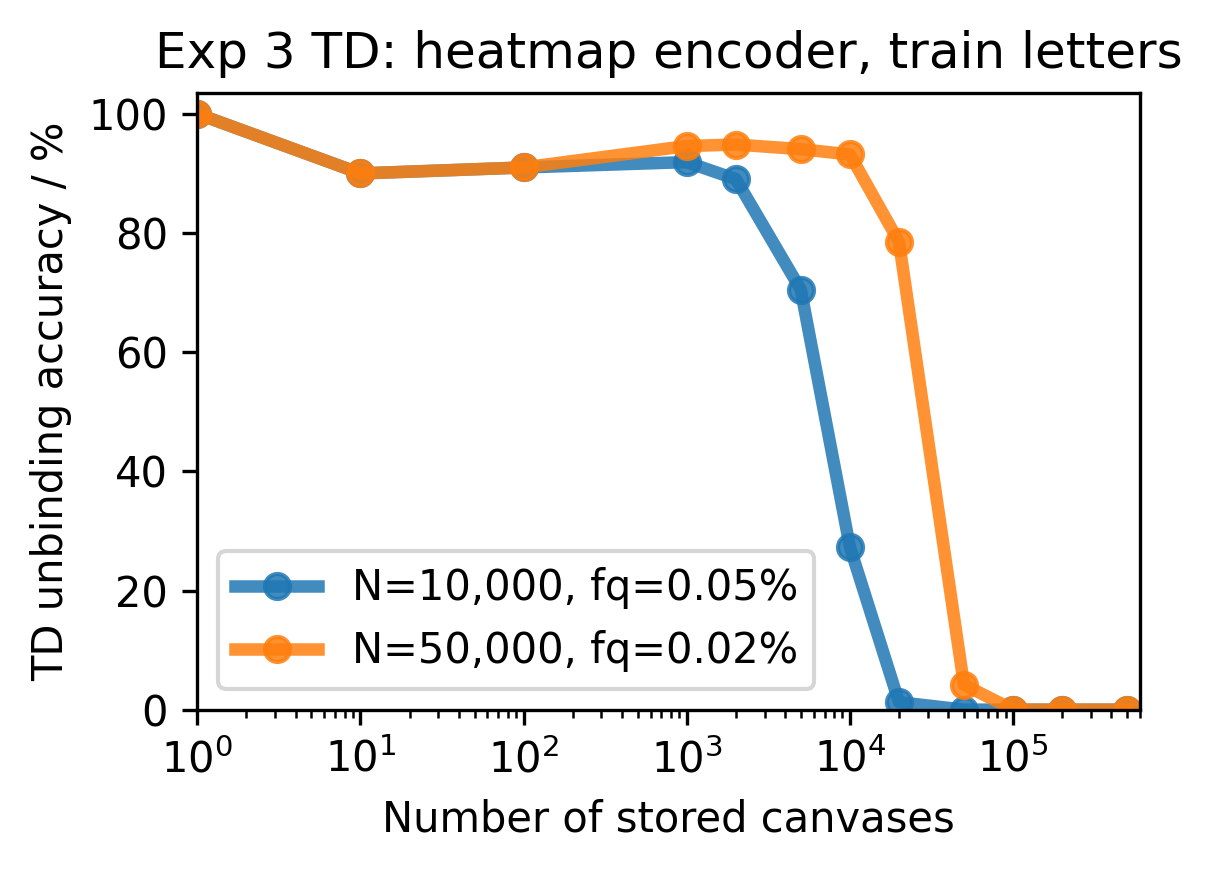

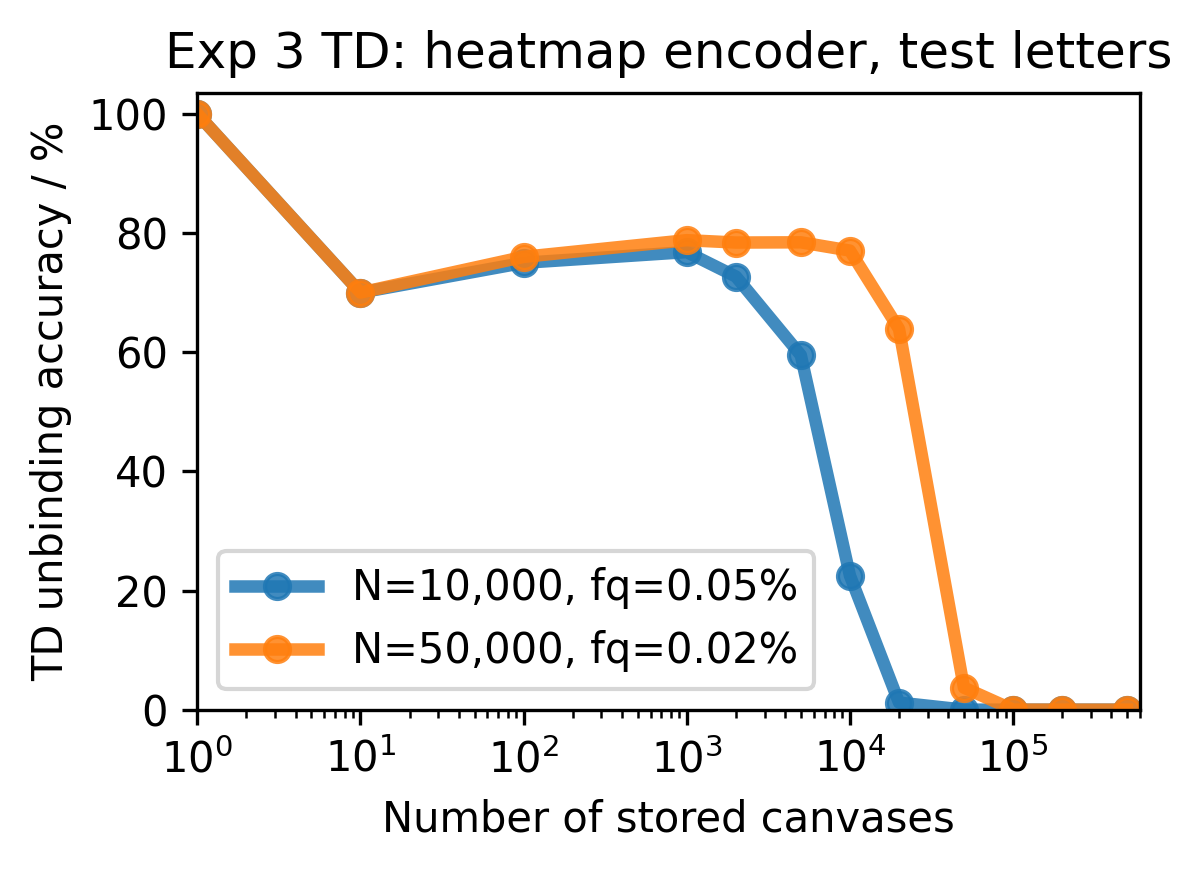


========== Summary ==========

 train_exp3_10000_0.0005
x_range         : [     1     10    100   1000   2000   5000  10000  20000  50000 100000
 200000 500000]
scene_exact_acc : [1.     0.9    0.91   0.919  0.8905 0.7048 0.273  0.0125 0.     0.
 0.     0.    ]
exact_acc       : [1.     0.9    0.91   0.919  0.8905 0.7048 0.273  0.0125 0.     0.
 0.     0.    ]
bit_acc         : [1.     0.9996 0.9995 0.999  0.9985 0.9955 0.9874 0.9835 0.9817 0.9779
 0.9701 0.9655]
n_eval          : [    1    10   100  1000  2000  5000 10000 10000 10000 10000 10000 10000]

 train_exp3_50000_0.0002
x_range         : [     1     10    100   1000   2000   5000  10000  20000  50000 100000
 200000 500000]
scene_exact_acc : [1.     0.9    0.91   0.946  0.9485 0.9408 0.9318 0.785  0.0419 0.
 0.     0.    ]
exact_acc       : [1.     0.9    0.91   0.946  0.9485 0.9408 0.9318 0.785  0.0419 0.
 0.     0.    ]
bit_acc         : [1.     0.9996 0.9995 0.9997 0.9997 0.9997 0.9996 0.9983 0.9933 0.9857
 0.9788 0.9777]
n

In [4]:
# ============================================================
# Exp 3 TD unbinding with trained heatmap model as visual encoder
#
# Scene code:
#   one letter = one-hot(label) + one-hot(x) + one-hot(y)
#   3 letters  = concatenation of 3 letter codes
#   total active bits = 9
#
# This code assumes the CenterHeatmapDetector code above is already defined.
# It uses:
#   ./runs/model_latest_heatmap.pt
# ============================================================

import os
import json
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
from torch.utils.data import DataLoader


# ============================================================
# Config
# ============================================================

TD_CACHE_DIR = "./td_heatmap_encoder_results_randomslots_new_shared_canvases"
os.makedirs(TD_CACHE_DIR, exist_ok=True)

MODEL_PATH = "./runs_heatmap_corner_blocked_train_only/model_latest_heatmap.pt"

canvas_size = 64
object_size = 28
k = 3
emnist_split = "letters"
RANDOMIZE_SLOTS = True

N_LETTERS = 26
IMG_SIZE = canvas_size

INPUT_SIZE = N_LETTERS + IMG_SIZE + IMG_SIZE
FULL_SIZE = INPUT_SIZE * 3

X_RANGE_EXP3 = [
    1, 10, 100, 1000, 2000, 5000, 10000,
    20000, 50000, 100000, 200000, 500000
]

HP_SETS = [
    {
        "n_post": 10000,
        "p": 0.0005,
        "label": "N=10,000, fq=0.05%",
        "color": "tab:blue",
    },
    {
        "n_post": 50000,
        "p": 0.0002,
        "label": "N=50,000, fq=0.02%",
        "color": "tab:orange",
    },
]

EVAL_MAX_ITEMS_EXP3 = 10000
threshold_exp3 = 7

batch_size_encoder = 512
batch_size_data = 512

max_exp3 = max(X_RANGE_EXP3)


# ============================================================
# Safe cache helpers
# ============================================================

def save_npz_safe(path, **kwargs):
    tmp_path = path + ".tmp.npz"
    np.savez_compressed(tmp_path, **kwargs)

    if os.path.exists(path):
        os.remove(path)

    os.rename(tmp_path, path)


def load_npz_dict(path):
    data = np.load(path, allow_pickle=True)
    return {k: data[k] for k in data.files}


def save_json(path, obj):
    tmp_path = path + ".tmp"

    with open(tmp_path, "w") as f:
        json.dump(obj, f, indent=2)

    if os.path.exists(path):
        os.remove(path)

    os.rename(tmp_path, path)


# ============================================================
# Load trained heatmap model
# ============================================================

def load_heatmap_encoder(model_path=MODEL_PATH, device=None):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    ckpt = torch.load(model_path, map_location=device)

    model = CenterHeatmapDetector(
        num_classes=ckpt.get("num_classes", 26),
        base_ch=64,
        canvas_size=ckpt.get("canvas_size", 64),
        object_size=ckpt.get("object_size", 28),
    ).to(device)

    if "model_state_dict" in ckpt:
        state = ckpt["model_state_dict"]
    else:
        state = ckpt["model"]

    model.load_state_dict(state)
    model.eval()

    print("Loaded encoder:", model_path)
    print("checkpoint epoch:", ckpt.get("epoch", None))
    print("checkpoint global_step:", ckpt.get("global_step", None))

    return model, ckpt, device


model_encoder, model_ckpt, device = load_heatmap_encoder(MODEL_PATH)


# ============================================================
# Encoding without color
# ============================================================

def encode_letter_no_color(letter_idx, x, y):
    # One can pad many zeros to make this vec a 10,000 dimensional long sparse vector
    vec = np.zeros(INPUT_SIZE, dtype=np.uint8)

    if letter_idx is not None:
        vec[int(letter_idx)] = 1

    if x is not None:
        vec[N_LETTERS + int(x)] = 1

    if y is not None:
        vec[N_LETTERS + IMG_SIZE + int(y)] = 1

    return vec


def canonicalize_scene_labelxy(scene):
    scene = [tuple(map(int, row)) for row in scene]
    return sorted(scene, key=lambda z: (z[1], z[2], z[0]))


def keep_scene_order_labelxy(scene):
    return [tuple(map(int, row)) for row in scene]


def encode_full_scene_no_color(scene):
    scene = keep_scene_order_labelxy(scene)

    return np.concatenate([
        encode_letter_no_color(letter_idx, x, y)
        for letter_idx, x, y in scene
    ]).astype(np.uint8)

def scenes_to_full_vectors_no_color_cached(scenes, cache_path, desc="encoding scenes"):
    if os.path.exists(cache_path):
        print("Loading encoded vectors:", cache_path)
        return np.load(cache_path)

    arr = np.zeros((len(scenes), FULL_SIZE), dtype=np.uint8)

    for i in tqdm(range(len(scenes)), desc=desc):
        arr[i] = encode_full_scene_no_color(scenes[i])

    np.save(cache_path, arr)
    print("Saved encoded vectors:", cache_path)

    return arr


def wta_decode_full_no_color(reconstruct):
    decoded = np.zeros(FULL_SIZE, dtype=np.uint8)

    for part in range(3):
        base = part * INPUT_SIZE

        i = np.argmax(reconstruct[base : base + N_LETTERS])
        decoded[base + i] = 1

        offset = base + N_LETTERS
        i = np.argmax(reconstruct[offset : offset + IMG_SIZE])
        decoded[offset + i] = 1

        offset += IMG_SIZE
        i = np.argmax(reconstruct[offset : offset + IMG_SIZE])
        decoded[offset + i] = 1

    return decoded


def full_vector_to_scene_no_color(vec):
    scene = []

    for part in range(3):
        base = part * INPUT_SIZE

        letter_idx = int(np.argmax(vec[base : base + N_LETTERS]))

        offset = base + N_LETTERS
        x = int(np.argmax(vec[offset : offset + IMG_SIZE]))

        offset += IMG_SIZE
        y = int(np.argmax(vec[offset : offset + IMG_SIZE]))

        scene.append((letter_idx, x, y))

    return canonicalize_scene_labelxy(scene)

from itertools import permutations

def scene_match_tolerant_labelxy(pred_scene, target_scene, xy_tol=1):
    """
    pred_scene and target_scene:
        list of 3 tuples:
            (letter_idx, x, y)

    A predicted object is correct if:
        label matches
        |x_pred - x_gt| <= xy_tol
        |y_pred - y_gt| <= xy_tol

    Because object order is not meaningful, we try all 3! matchings.
    """

    pred_scene = [tuple(map(int, row)) for row in pred_scene]
    target_scene = [tuple(map(int, row)) for row in target_scene]

    K = len(pred_scene)

    for p in permutations(range(K)):
        ok = True

        for i in range(K):
            lp, xp, yp = pred_scene[i]
            lt, xt, yt = target_scene[p[i]]

            if lp != lt:
                ok = False
                break

            if abs(xp - xt) > xy_tol:
                ok = False
                break

            if abs(yp - yt) > xy_tol:
                ok = False
                break

        if ok:
            return True

    return False


def vector_match_tolerant_labelxy(pred_vec, target_vec, xy_tol=1):
    pred_scene = full_vector_to_scene_no_color(pred_vec)
    target_scene = full_vector_to_scene_no_color(target_vec)

    return scene_match_tolerant_labelxy(
        pred_scene=pred_scene,
        target_scene=target_scene,
        xy_tol=xy_tol,
    )

# ============================================================
# Convert boxes to integer centers
# ============================================================

def boxes_to_integer_centers_numpy(boxes, canvas_size=64):
    cx = np.rint((boxes[..., 0] + boxes[..., 2]) * 0.5 * canvas_size).astype(np.int16)
    cy = np.rint((boxes[..., 1] + boxes[..., 3]) * 0.5 * canvas_size).astype(np.int16)

    cx = np.clip(cx, 0, canvas_size - 1)
    cy = np.clip(cy, 0, canvas_size - 1)

    return cx, cy


@torch.no_grad()
def detect_batch_as_labelxy(model, x, device, k=3, canvas_size=64, object_size=28):
    x = x.to(device, non_blocking=True)

    logits = model(x)

    pred_boxes, pred_labels, pred_scores = decode_heatmap_topk(
        logits=logits,
        k=k,
        canvas_size=canvas_size,
        object_size=object_size,
    )

    pred_boxes = pred_boxes.detach().cpu().numpy()
    pred_labels = pred_labels.detach().cpu().numpy().astype(np.int16)

    pred_cx, pred_cy = boxes_to_integer_centers_numpy(
        pred_boxes,
        canvas_size=canvas_size,
    )

    B = pred_labels.shape[0]
    scenes = np.zeros((B, k, 3), dtype=np.int16)

    for i in range(B):
        objs = []

        for j in range(k):
            objs.append((
                int(pred_labels[i, j]),
                int(pred_cx[i, j]),
                int(pred_cy[i, j]),
            ))

        scenes[i] = np.asarray(
            canonicalize_scene_labelxy(objs),
            dtype=np.int16,
        )

    return scenes


def gt_batch_as_labelxy(gt_boxes, gt_labels, canvas_size=64, k=3):
    gt_boxes = gt_boxes.detach().cpu().numpy()
    gt_labels = gt_labels.detach().cpu().numpy().astype(np.int16)

    gt_cx, gt_cy = boxes_to_integer_centers_numpy(
        gt_boxes,
        canvas_size=canvas_size,
    )

    B = gt_labels.shape[0]
    scenes = np.zeros((B, k, 3), dtype=np.int16)

    for i in range(B):
        objs = []

        for j in range(k):
            objs.append((
                int(gt_labels[i, j]),
                int(gt_cx[i, j]),
                int(gt_cy[i, j]),
            ))

        scenes[i] = np.asarray(
            canonicalize_scene_labelxy(objs),
            dtype=np.int16,
        )

    return scenes

def randomize_slot_order_pair_labelxy(gt_scene, det_scene, rng):
    gt_aligned = np.asarray(canonicalize_scene_labelxy(gt_scene), dtype=np.int16)
    det_aligned = np.asarray(canonicalize_scene_labelxy(det_scene), dtype=np.int16)

    perm = rng.permutation(3)

    return gt_aligned[perm], det_aligned[perm]


def randomize_slot_order_pool_labelxy(gt_scenes, det_scenes, seed=0):
    rng = np.random.default_rng(seed)

    gt_out = np.zeros_like(gt_scenes, dtype=np.int16)
    det_out = np.zeros_like(det_scenes, dtype=np.int16)

    for i in tqdm(range(len(gt_scenes)), desc="randomizing slot order"):
        gt_out[i], det_out[i] = randomize_slot_order_pair_labelxy(
            gt_scene=gt_scenes[i],
            det_scene=det_scenes[i],
            rng=rng,
        )

    return gt_out, det_out
# ============================================================
# Build train-only or test-only visual-encoder pools
# ============================================================
def build_heatmap_encoder_pool_cached(
    split_name,
    train_flag,
    max_images,
    seed,
    model,
    device,
    rebuild=False,
    save_every_batches=20,
    randomize_slots=True,
):
    """
    Uses the same canvases as your previous random-slot experiment.

    Important:
    - same ThreeCharEMNIST seed
    - same train/test flag
    - same placement settings
    - same slot_seed = seed + 999

    But it recomputes det_scenes with the current encoder.
    """

    old_base_scene_cache_path = os.path.join(
        TD_CACHE_DIR,
        f"exp3_{split_name}_base_scenes_n{max_images}_seed{seed}.npz"
    )

    ckpt_tag = os.path.basename(MODEL_PATH).replace(".pt", "")
    ckpt_epoch = model_ckpt.get("epoch", "unknown")
    ckpt_step = model_ckpt.get("global_step", "unknown")

    new_encoder_scene_cache_path = os.path.join(
        TD_CACHE_DIR,
        f"exp3_{split_name}_{ckpt_tag}_ep{ckpt_epoch}_step{ckpt_step}_same_canvases_scenes_n{max_images}_seed{seed}.npz"
    )

    slot_seed = seed + 999

    randomized_scene_cache_path = os.path.join(
        TD_CACHE_DIR,
        f"exp3_{split_name}_{ckpt_tag}_ep{ckpt_epoch}_step{ckpt_step}_same_canvases_rand{int(randomize_slots)}_slotseed{slot_seed}.npz"
    )

    det_full_path = os.path.join(
        TD_CACHE_DIR,
        f"exp3_{split_name}_{ckpt_tag}_ep{ckpt_epoch}_step{ckpt_step}_same_canvases_det_full_n{max_images}_seed{seed}_rand{int(randomize_slots)}_slotseed{slot_seed}.npy"
    )

    gt_full_path = os.path.join(
        TD_CACHE_DIR,
        f"exp3_{split_name}_{ckpt_tag}_ep{ckpt_epoch}_step{ckpt_step}_same_canvases_gt_full_n{max_images}_seed{seed}_rand{int(randomize_slots)}_slotseed{slot_seed}.npy"
    )

    # --------------------------------------------------------
    # If current-encoder cache exists, load it
    # --------------------------------------------------------

    if os.path.exists(new_encoder_scene_cache_path) and not rebuild:
        obj = load_npz_dict(new_encoder_scene_cache_path)

        gt_scenes = obj["gt_scenes"]
        det_scenes = obj["det_scenes"]
        done = int(obj.get("done", max_images))

        print("Loaded current-encoder scene cache:", new_encoder_scene_cache_path)
        print(f"done={done}/{max_images}")

        if done < max_images:
            print("Current-encoder cache incomplete. Resume encoding.")

    else:
        gt_scenes = np.zeros((max_images, k, 3), dtype=np.int16)
        det_scenes = np.zeros((max_images, k, 3), dtype=np.int16)
        done = 0

        print("Starting current-encoder scene encoding:")
        print(new_encoder_scene_cache_path)

    # --------------------------------------------------------
    # Optional sanity check against previous base cache
    # This does not reuse old det_scenes.
    # --------------------------------------------------------

    old_gt_scenes = None

    if os.path.exists(old_base_scene_cache_path):
        old_obj = load_npz_dict(old_base_scene_cache_path)
        old_gt_scenes = old_obj["gt_scenes"]

        print("Found previous base scene cache:")
        print(old_base_scene_cache_path)
        print("Will use it only for GT sanity check, not for old detections.")

    # --------------------------------------------------------
    # Recreate the exact same canvases by using same dataset seed/settings
    # --------------------------------------------------------

    if (not os.path.exists(new_encoder_scene_cache_path)) or rebuild or done < max_images:
        ds = ThreeCharEMNIST(
            root="./data",
            train=train_flag,
            split=emnist_split,
            canvas_size=canvas_size,
            chars_per_image=k,
            length=max_images,
            seed=seed,
            allow_overlap=False,
            placement_tries=80,
            min_separation=2,
            augment=False,
            use_class_corner_blocking=False,
            max_canvas_resample=100,
        )

        loader = DataLoader(
            ds,
            batch_size=batch_size_encoder,
            shuffle=False,
            num_workers=0,
            pin_memory=True,
        )

        model.eval()

        batch_counter = 0
        current_start = 0

        for x, gt_boxes, gt_labels in tqdm(
            loader,
            desc=f"encoding {split_name} with current heatmap model on same canvases",
        ):
            B = x.shape[0]
            current_end = current_start + B

            if current_end <= done:
                current_start = current_end
                continue

            if current_start < done < current_end:
                keep_from = done - current_start

                x = x[keep_from:]
                gt_boxes = gt_boxes[keep_from:]
                gt_labels = gt_labels[keep_from:]

                current_start = done
                B = x.shape[0]
                current_end = current_start + B

            gt_batch = gt_batch_as_labelxy(
                gt_boxes=gt_boxes,
                gt_labels=gt_labels,
                canvas_size=canvas_size,
                k=k,
            )

            det_batch = detect_batch_as_labelxy(
                model=model,
                x=x,
                device=device,
                k=k,
                canvas_size=canvas_size,
                object_size=object_size,
            )

            

            # sanity check: regenerated GT should match old base GT
            if old_gt_scenes is not None:
                old_batch = old_gt_scenes[current_start:current_end]

                if not np.array_equal(gt_batch, old_batch):
                    print(
                        f"Warning: regenerated GT does not match old cache at "
                        f"{current_start}:{current_end}. "
                        f"Using old GT scenes for fair comparison."
                    )

                gt_batch = old_batch
                
            gt_scenes[current_start:current_end] = gt_batch
            det_scenes[current_start:current_end] = det_batch

            done = current_end
            batch_counter += 1

            if batch_counter % save_every_batches == 0 or done >= max_images:
                partial_exact_scene_acc = float(
                    np.mean(np.all(
                        det_scenes[:done] == gt_scenes[:done],
                        axis=(1, 2)
                    ))
                )

                save_npz_safe(
                    new_encoder_scene_cache_path,
                    gt_scenes=gt_scenes,
                    det_scenes=det_scenes,
                    done=np.array(done, dtype=np.int64),
                    partial_exact_scene_acc=np.array(partial_exact_scene_acc, dtype=np.float32),
                    model_path=np.array(MODEL_PATH),
                    old_base_scene_cache_path=np.array(old_base_scene_cache_path),
                )

                print(
                    f"Saved current-encoder scene cache: "
                    f"done={done}/{max_images}, "
                    f"partial_exact_scene_acc={partial_exact_scene_acc:.4f}"
                )
                        
            current_start = current_end

        exact_scene_acc = float(
            np.mean(np.all(det_scenes == gt_scenes, axis=(1, 2)))
        )

        print(f"{split_name} current encoder exact scene acc: {exact_scene_acc:.4f}")

        save_npz_safe(
            new_encoder_scene_cache_path,
            gt_scenes=gt_scenes,
            det_scenes=det_scenes,
            done=np.array(max_images, dtype=np.int64),
            exact_scene_acc=np.array(exact_scene_acc, dtype=np.float32),
            model_path=np.array(MODEL_PATH),
            old_base_scene_cache_path=np.array(old_base_scene_cache_path),
        )

        save_json(
            new_encoder_scene_cache_path.replace(".npz", "_meta.json"),
            {
                "split_name": split_name,
                "train_flag": bool(train_flag),
                "max_images": int(max_images),
                "seed": int(seed),
                "model_path": MODEL_PATH,
                "old_base_scene_cache_path": old_base_scene_cache_path,
                "slot_seed": int(slot_seed),
                "same_canvases_as_previous_randomslot_run": True,
                "code": "same deterministic canvases, new encoder detections",
            },
        )

    # --------------------------------------------------------
    # Apply the same slot randomization as before
    # --------------------------------------------------------

    if os.path.exists(randomized_scene_cache_path) and not rebuild:
        obj = load_npz_dict(randomized_scene_cache_path)

        gt_scenes_work = obj["gt_scenes"]
        det_scenes_work = obj["det_scenes"]

        print("Loaded randomized working scene cache:", randomized_scene_cache_path)

    else:
        if randomize_slots:
            gt_scenes_work, det_scenes_work = randomize_slot_order_pool_labelxy(
                gt_scenes=gt_scenes,
                det_scenes=det_scenes,
                seed=slot_seed,
            )
        else:
            gt_scenes_work = gt_scenes.copy()
            det_scenes_work = det_scenes.copy()

        save_npz_safe(
            randomized_scene_cache_path,
            gt_scenes=gt_scenes_work,
            det_scenes=det_scenes_work,
            randomize_slots=np.array(int(randomize_slots), dtype=np.int32),
            slot_seed=np.array(slot_seed, dtype=np.int64),
            model_path=np.array(MODEL_PATH),
        )

        print("Saved randomized working scene cache:", randomized_scene_cache_path)

    # --------------------------------------------------------
    # Encode vectors
    # --------------------------------------------------------

    gt_full = scenes_to_full_vectors_no_color_cached(
        gt_scenes_work,
        cache_path=gt_full_path,
        desc=f"encoding {split_name} GT full vectors",
    )

    det_full = scenes_to_full_vectors_no_color_cached(
        det_scenes_work,
        cache_path=det_full_path,
        desc=f"encoding {split_name} visual-encoder full vectors",
    )

    return gt_scenes_work, det_scenes_work, det_full, gt_full

# ============================================================
# Memory model
# ============================================================

def memory_update(W_ff, W_fb, full_input, rng, p):
    selected = rng.random(W_ff.shape[0]) <= p

    if not np.any(selected):
        return

    sel_idx = np.flatnonzero(selected)
    active_idx = np.flatnonzero(full_input)

    if len(active_idx) == 0:
        return

    sub = W_ff[np.ix_(sel_idx, active_idx)]
    set_to_1 = sub == 0

    W_ff[np.ix_(sel_idx, active_idx)] = 1 - sub

    rows, cols = np.where(set_to_1.T)

    if len(rows) > 0:
        W_fb[active_idx[rows], sel_idx[cols]] = 1


def evaluate_memory_td_no_color(
    W_ff,
    W_fb,
    cues,
    targets,
    threshold,
    max_items=None,
    xy_tol=1,
):
    n_total = len(cues)

    if max_items is None or max_items >= n_total:
        eval_idx = np.arange(n_total)
    else:
        eval_idx = np.linspace(0, n_total - 1, max_items).astype(int)

    W_ff_i = W_ff.astype(np.int16, copy=False)
    W_fb_i = W_fb.astype(np.int16, copy=False)

    bit_accs = []
    exacts = []
    scene_exacts = []
    scene_tolerant_exacts = []

    for idx in eval_idx:
        cue = cues[idx].astype(np.int16, copy=False)
        target = targets[idx].astype(np.uint8, copy=False)

        hidden = (W_ff_i @ cue) > threshold
        reconstruct = W_fb_i @ hidden.astype(np.int16)

        decoded = wta_decode_full_no_color(reconstruct)

        bit_accs.append(np.mean(decoded == target))
        exacts.append(float(np.array_equal(decoded, target)))

        decoded_scene = full_vector_to_scene_no_color(decoded)
        target_scene = full_vector_to_scene_no_color(target)

        scene_exacts.append(float(decoded_scene == target_scene))

        tolerant_ok = scene_match_tolerant_labelxy(
            pred_scene=decoded_scene,
            target_scene=target_scene,
            xy_tol=xy_tol,
        )

        scene_tolerant_exacts.append(float(tolerant_ok))

    return {
        "bit_acc": float(np.mean(bit_accs)),
        "exact_acc": float(np.mean(exacts)),
        "scene_exact_acc": float(np.mean(scene_exacts)),
        "scene_tolerant_exact_acc": float(np.mean(scene_tolerant_exacts)),
        "xy_tol": int(xy_tol),
        "n_eval": int(len(eval_idx)),
    }


def run_curve_incremental_checkpointed_td_no_color(
    train_vectors,
    cue_vectors,
    target_vectors,
    x_range,
    n_post,
    p,
    threshold,
    seed=0,
    max_eval_items=None,
    cache_name="experiment",
    cache_dir=TD_CACHE_DIR,
    force_restart=False,
):
#     seed=10
    os.makedirs(cache_dir, exist_ok=True)

    ckpt_path = os.path.join(
        cache_dir,
        f"{cache_name}_npost{n_post}_p{p}_thr{threshold}_seed{seed}.npz"
    )

    x_range = list(x_range)
    max_n = max(x_range)
    x_set = set(x_range)

    rng = np.random.default_rng(seed)

    if os.path.exists(ckpt_path) and not force_restart:
        print("Loading memory checkpoint:", ckpt_path)

        ckpt = np.load(ckpt_path, allow_pickle=True)

        W_ff = ckpt["W_ff"]
        W_fb = ckpt["W_fb"]
        start_i = int(ckpt["current_i"])

        results = {
            "x_range": ckpt["x_range"].tolist(),
            "bit_acc": ckpt["bit_acc"].tolist(),
            "exact_acc": ckpt["exact_acc"].tolist(),
            "scene_exact_acc": ckpt["scene_exact_acc"].tolist(),
            "scene_tolerant_exact_acc": ckpt["scene_tolerant_exact_acc"].tolist()
                if "scene_tolerant_exact_acc" in ckpt.files else [],
            "n_eval": ckpt["n_eval"].tolist(),
        }

        rng_state = ckpt["rng_state"].item()
        rng.bit_generator.state = rng_state

        print(f"Resuming from sample {start_i}")
        print("Finished datapoints:", results["x_range"])

    else:
        print("Starting new memory run:", ckpt_path)

        W_ff = np.zeros((n_post, FULL_SIZE), dtype=np.uint8)
        W_fb = np.zeros((FULL_SIZE, n_post), dtype=np.uint8)

        start_i = 0

        results = {
            "x_range": [],
            "bit_acc": [],
            "exact_acc": [],
            "scene_exact_acc": [],
            "scene_tolerant_exact_acc": [],
            "n_eval": [],
        }

    for i in tqdm(range(start_i, max_n), desc=f"training {cache_name}, N={n_post}, p={p}"):
        memory_update(
            W_ff=W_ff,
            W_fb=W_fb,
            full_input=train_vectors[i],
            rng=rng,
            p=p,
        )

        current_n = i + 1

        if current_n in x_set:
            stats = evaluate_memory_td_no_color(
                W_ff=W_ff,
                W_fb=W_fb,
                cues=cue_vectors[:current_n],
                targets=target_vectors[:current_n],
                threshold=threshold,
                max_items=max_eval_items,
                xy_tol=2,
            )


            print(
                f"{cache_name}, N={n_post}, p={p}, samples={current_n}, "
                f"bit_acc={stats['bit_acc']:.4f}, "
                f"exact_acc={stats['exact_acc']:.4f}, "
                f"scene_exact_acc={stats['scene_exact_acc']:.4f}, "
                f"scene_tol_acc={stats['scene_tolerant_exact_acc']:.4f}, "
                f"n_eval={stats['n_eval']}"
            )

            if current_n not in results["x_range"]:
                results["x_range"].append(current_n)
                results["bit_acc"].append(stats["bit_acc"])
                results["exact_acc"].append(stats["exact_acc"])
                results["scene_exact_acc"].append(stats["scene_exact_acc"])
                results["scene_tolerant_exact_acc"].append(stats["scene_tolerant_exact_acc"])
                results["n_eval"].append(stats["n_eval"])



            save_npz_safe(
                ckpt_path,
                W_ff=W_ff,
                W_fb=W_fb,
                current_i=np.array(current_n, dtype=np.int64),
                x_range=np.asarray(results["x_range"]),
                bit_acc=np.asarray(results["bit_acc"]),
                exact_acc=np.asarray(results["exact_acc"]),
                scene_exact_acc=np.asarray(results["scene_exact_acc"]),
                scene_tolerant_exact_acc=np.asarray(results["scene_tolerant_exact_acc"]),
                n_eval=np.asarray(results["n_eval"]),
                rng_state=np.array(rng.bit_generator.state, dtype=object),
            )

            print("Saved memory checkpoint:", ckpt_path)

    final_results = {
        "x_range": np.asarray(results["x_range"]),
        "bit_acc": np.asarray(results["bit_acc"]),
        "exact_acc": np.asarray(results["exact_acc"]),
        "scene_exact_acc": np.asarray(results["scene_exact_acc"]),
        "scene_tolerant_exact_acc": np.asarray(results["scene_tolerant_exact_acc"]),
        "n_eval": np.asarray(results["n_eval"]),
    }

    final_path = os.path.join(
        cache_dir,
        f"{cache_name}_npost{n_post}_p{p}_thr{threshold}_seed{seed}_final.npy"
    )

    np.save(final_path, final_results, allow_pickle=True)

    print("Saved final memory results:", final_path)

    return final_results


# ============================================================
# Plotting
# ============================================================

def plot_td_pair(res_10000, res_50000, title, xlim=(1, 600000), ylim=(0, 103.5)):
    plt.figure(figsize=(4, 3), dpi=300)

    plt.plot(
        res_10000["x_range"],
        res_10000["scene_exact_acc"] * 100,
        marker="o",
        lw=3,
        label="N=10,000, fq=0.05%",
        color="tab:blue",
        alpha=0.85,
    )

    plt.plot(
        res_50000["x_range"],
        res_50000["scene_exact_acc"] * 100,
        marker="o",
        lw=3,
        label="N=50,000, fq=0.02%",
        color="tab:orange",
        alpha=0.85,
    )

    plt.xscale("log")
    plt.xlim(*xlim)
    plt.ylim(*ylim)

    plt.xlabel("Number of stored canvases")
    plt.ylabel("TD unbinding accuracy / %")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ============================================================
# Prepare data
# ============================================================

print("\n========== Prepare Exp 3 train-letter pool ==========")

gt_scenes_train, det_scenes_train, det_full_train, gt_full_train = build_heatmap_encoder_pool_cached(
    split_name="train_letters",
    train_flag=True,
    max_images=max_exp3,
    seed=333,
    model=model_encoder,
    device=device,
    rebuild=True,
    randomize_slots=RANDOMIZE_SLOTS,
)

rng = np.random.default_rng(2)

perm_train = rng.permutation(len(det_full_train))

det_full_train = det_full_train[perm_train]
gt_full_train = gt_full_train[perm_train]

det_scenes_train = det_scenes_train[perm_train]
gt_scenes_train = gt_scenes_train[perm_train]

print("\n========== Prepare Exp 3 test-letter pool ==========")

gt_scenes_test, det_scenes_test, det_full_test, gt_full_test = build_heatmap_encoder_pool_cached(
    split_name="test_letters",
    train_flag=False,
    max_images=max_exp3,
    seed=444,
    model=model_encoder,
    device=device,
    rebuild=True,
    randomize_slots=RANDOMIZE_SLOTS,
)

rng = np.random.default_rng(2)

perm_test = rng.permutation(len(det_full_test))

det_full_test = det_full_test[perm_test]
gt_full_test = gt_full_test[perm_test]

det_scenes_test = det_scenes_test[perm_test]
gt_scenes_test = gt_scenes_test[perm_test]


# ============================================================
# Run train-only Exp 3
# ============================================================

all_results = {}

print("\n========== Exp 3 TD: train letters only ==========")

for hp in HP_SETS:
    res = run_curve_incremental_checkpointed_td_no_color(
        train_vectors=det_full_train,
        cue_vectors=det_full_train,
        target_vectors=gt_full_train,
        x_range=X_RANGE_EXP3,
        n_post=hp["n_post"],
        p=hp["p"],
        threshold=threshold_exp3,
        seed=3000 + hp["n_post"],
        max_eval_items=EVAL_MAX_ITEMS_EXP3,
        cache_name="centerCNN_exp3_TD_heatmap_encoder_train_letters_rand_slots_same_canvases_new_encoder",
        force_restart=False,
    )

    all_results[f"train_exp3_{hp['n_post']}_{hp['p']}"] = res


# ============================================================
# Run test-only Exp 3
# ============================================================

print("\n========== Exp 3 TD: test letters only ==========")

for hp in HP_SETS:
    res = run_curve_incremental_checkpointed_td_no_color(
        train_vectors=det_full_test,
        cue_vectors=det_full_test,
        target_vectors=gt_full_test,
        x_range=X_RANGE_EXP3,
        n_post=hp["n_post"],
        p=hp["p"],
        threshold=threshold_exp3,
        seed=4000 + hp["n_post"],
        max_eval_items=EVAL_MAX_ITEMS_EXP3,
        cache_name="centerCNN_exp3_TD_heatmap_encoder_test_letters_rand_slots_same_canvases_new_encoder",
        force_restart=False,
    )

    all_results[f"test_exp3_{hp['n_post']}_{hp['p']}"] = res


# ============================================================
# Save and plot
# ============================================================

all_results_path = os.path.join(
    TD_CACHE_DIR,
    "all_exp3_td_heatmap_encoder_results.npy"
)

np.save(all_results_path, all_results, allow_pickle=True)

print("Saved all results:", all_results_path)

plot_td_pair(
    res_10000=all_results["train_exp3_10000_0.0005"],
    res_50000=all_results["train_exp3_50000_0.0002"],
    title="Exp 3 TD: heatmap encoder, train letters",
    xlim=(1, 600000),
    ylim=(0, 103.5),
)

plot_td_pair(
    res_10000=all_results["test_exp3_10000_0.0005"],
    res_50000=all_results["test_exp3_50000_0.0002"],
    title="Exp 3 TD: heatmap encoder, test letters",
    xlim=(1, 600000),
    ylim=(0, 103.5),
)


# ============================================================
# Summary
# ============================================================

print("\n========== Summary ==========")

for key, res in all_results.items():
    print("\n", key)
    print("x_range         :", res["x_range"])
    print("scene_exact_acc :", np.round(res["scene_exact_acc"], 4))
    print("exact_acc       :", np.round(res["exact_acc"], 4))
    print("bit_acc         :", np.round(res["bit_acc"], 4))
    print("n_eval          :", res["n_eval"])

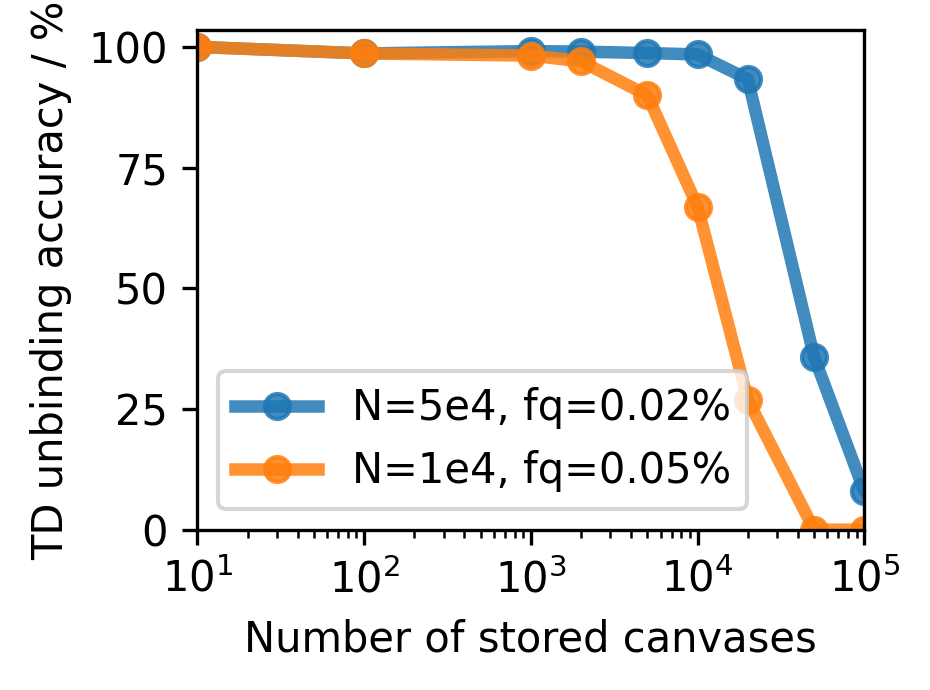

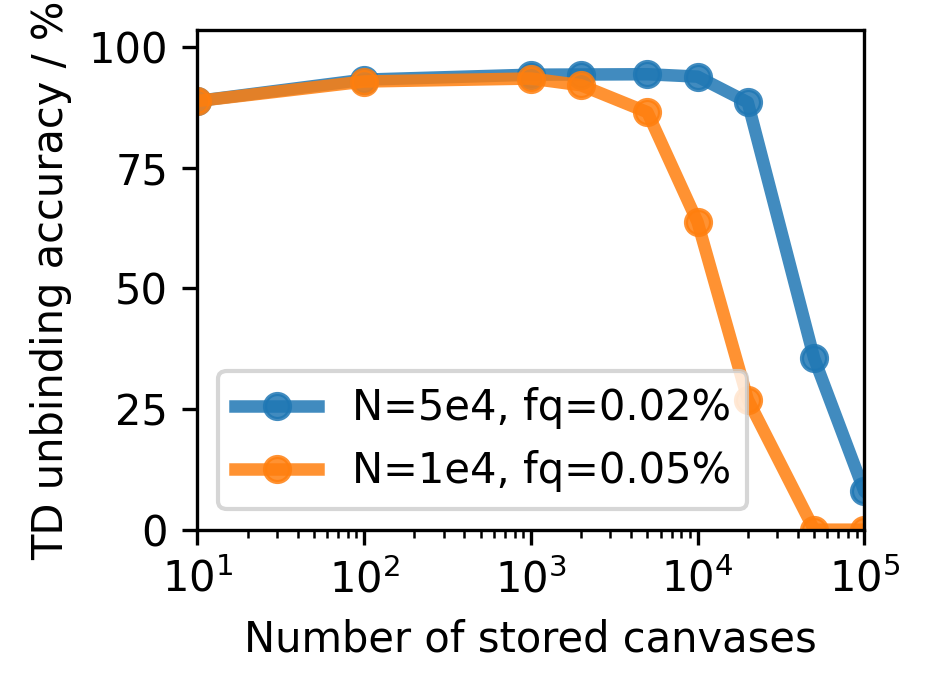

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
TD_CACHE_DIR = "./td_heatmap_encoder_results_randomslots_new_shared_canvases"

all_results_path = os.path.join(
    TD_CACHE_DIR,
    "all_exp3_td_heatmap_encoder_results.npy"
)

all_results = np.load(all_results_path, allow_pickle=True).item()


def plot_td_pair(res_10000, res_50000, title=None, xlim=(10, 600000), ylim=(0, 103.5)):
    
    plt.figure(figsize=(4*0.8,3*0.8),dpi=300)
    plt.plot(
        res_50000["x_range"][1:],
        np.cbrt(res_50000["scene_tolerant_exact_acc"])[1:] * 100,
        marker="o",
        lw=3,
        label="N=5e4, fq=0.02%",
        color="tab:blue",
        alpha=0.85,
    )
        
    plt.plot(
        res_10000["x_range"][1:],
        np.cbrt(res_10000["scene_tolerant_exact_acc"])[1:] * 100,
        marker="o",
        lw=3,
        label="N=1e4, fq=0.05%",
        color="tab:orange",
        alpha=0.85,
    )



    plt.xscale("log")
    plt.xlim(*xlim)
    plt.ylim(*ylim)

    plt.xlabel("Number of stored canvases")
    plt.ylabel("TD unbinding accuracy / %")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

    
plot_td_pair(
    res_10000=all_results["train_exp3_10000_0.0005"],
    res_50000=all_results["train_exp3_50000_0.0002"],
#     title="Exp 3 TD: heatmap encoder, train letters, randomized slots",
    xlim=(10, 100000),
    ylim=(0, 103.5),
)

plot_td_pair(
    res_10000=all_results["test_exp3_10000_0.0005"],
    res_50000=all_results["test_exp3_50000_0.0002"],
#     title="Exp 3 TD: heatmap encoder, test letters, randomized slots",
    xlim=(10, 100000),
    ylim=(0, 103.5),
)
